In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
df = pd.read_csv('dataset_clean.csv')



In [2]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)



In [3]:
print(f"Train: {len(train_df)} rows")
print(train_df['label'].value_counts())
print(f"\nTest: {len(test_df)} rows")
print(test_df['label'].value_counts())

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

Train: 9410 rows
label
Anxiety         3181
Depression      3118
SuicideWatch    3111
Name: count, dtype: int64

Test: 2353 rows
label
Anxiety         796
Depression      779
SuicideWatch    778
Name: count, dtype: int64


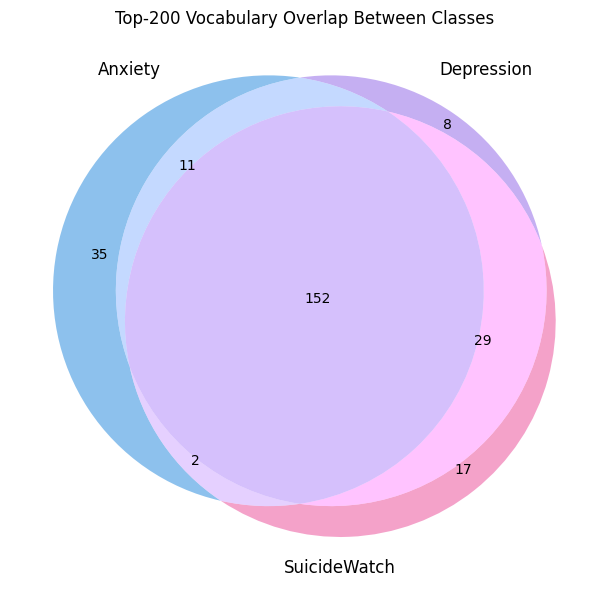

In [12]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def get_vocab(df, label, top_n=500):
    corpus = df[df['label'] == label]['clean_text']
    vec = CountVectorizer(max_features=top_n)
    vec.fit(corpus)
    return set(vec.get_feature_names_out())

anxiety_vocab    = get_vocab(train_df, 'Anxiety',      top_n=200)
depression_vocab = get_vocab(train_df, 'Depression',   top_n=200)
suicide_vocab    = get_vocab(train_df, 'SuicideWatch', top_n=200)

fig, ax = plt.subplots(figsize=(7, 6))
venn3(
    [anxiety_vocab, depression_vocab, suicide_vocab],
    set_labels=('Anxiety', 'Depression', 'SuicideWatch'),
    set_colors=('#4299E1', '#9F7AEA', '#ED64A6'),
    alpha=0.6,
    ax=ax
)
ax.set_title('Top-200 Vocabulary Overlap Between Classes', fontsize=12)
plt.tight_layout()
plt.savefig('vocab_overlap_venn.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
train_df['word_count'] = train_df['clean_text'].str.split().str.len()

print(train_df.groupby('label')['word_count'].median())
print(train_df.groupby('label')['word_count'].mean())
print(train_df.groupby('label')['word_count'].describe())

label
Anxiety         53.0
Depression      48.0
SuicideWatch    36.0
Name: word_count, dtype: float64
label
Anxiety         73.790946
Depression      72.796023
SuicideWatch    61.687239
Name: word_count, dtype: float64
               count       mean        std  min   25%   50%   75%     max
label                                                                    
Anxiety       3181.0  73.790946  75.430592  1.0  28.0  53.0  94.0  1030.0
Depression    3118.0  72.796023  93.315559  1.0  17.0  48.0  92.0  1194.0
SuicideWatch  3111.0  61.687239  83.334422  1.0  13.0  36.0  80.0  1318.0
